In [11]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_community.chat_models import ChatOllama

In [12]:
load_dotenv()

True

In [13]:
model = ChatOllama(
    model="phi3",
    temperature=0,
    num_predict=100
)

In [14]:
class BlogState(TypedDict):
    title:str
    outline:str
    content:str
    evaluate:str

In [15]:
def create_outline(state:BlogState)->BlogState:
    # fetch title
    print("create_outline is running")
    title =state['title']

    #call model gen outline
    prompt = f'Generate a short outline/summary for a blog on the topic {title}'
    outline = model.invoke(prompt).content

    #update state
    state['outline'] = outline
    return state

In [16]:
def create_blog(state:BlogState)->BlogState:
    print("create_blog is running")
    title = state['title']
    outline = state['outline']

    prompt = f'Write a short one line blog on the title - {title} using the following outline {outline}'

    content = model.invoke(prompt).content

    state['content'] = content
    return state

In [24]:
def evaluate_blog(state: BlogState)->BlogState:
    print("evaluate_blog is running")
    outline = state['outline']
    content = state['content']
    prompt = f'Give a rating out of 10 for the following blog content - {content} based on the following outline - {outline}. If the content is good and follows the outline well give a high rating else give a low rating'

    evaluate_blog = model.invoke(prompt).content
    state['evaluate'] = evaluate_blog
    return state

In [25]:
graph = StateGraph(BlogState)

#nodes
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
graph.add_node('evaluate_blog',evaluate_blog)
#edges
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog','evaluate_blog')
graph.add_edge('evaluate_blog',END)

workflow = graph.compile()

In [26]:
initial_state = {'title': 'Rise of AI in india'}
final_state = workflow.invoke(initial_state)
print(final_state)

create_outline is running
create_blog is running
evaluate_blog is running
{'title': 'Rise of AI in india', 'outline': "Title: The Rise of AI in India: A New Era of Innovation and Opportunity\n\nIntroduction\n- Briefly introduce the topic of AI and its potential impact on India' enduring growth and development.\n- Highlight the increasing adoption of AI in various sectors of the Indian economy.\n\nSection 1: The Current State of AI in India\n- Discuss the current state of AI in India, including the number of", 'content': '"The Rise of AI in India: A New Era of Innovation and Opportunity - As India embraces AI, it\'s poised to revolutionize its economy, with sectors like healthcare, education, and agriculture already witnessing transformative AI applications."\n\nIntroduction:\nArtificial Intelligence (AI) is rapidly becoming a cornerstone of India\'s burgeoning tech industry, promising to drive unprecedented', 'evaluate': "Rating: 8/10\n\nThe blog content provided offers a concise and i

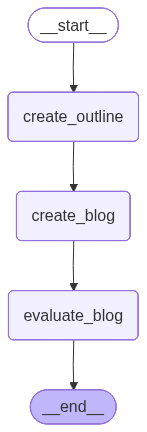

In [27]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())